Page 233 

Logistic Regression

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from sklearn.datasets import load_iris

In [4]:
iris = load_iris(as_frame = True)

In [5]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [6]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int64

In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Split the data and train a logistic regression model on the training set:

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
from sklearn.model_selection import train_test_split

In [12]:
X = iris.data[['petal width (cm)']].values

In [15]:
y = iris.target_names[iris.target] = 'virginica'

In [22]:
y = (iris.target == 2)

In [23]:
X.shape

(150, 1)

In [24]:
y.shape

(150,)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [26]:
log_reg = LogisticRegression(random_state = 42)

In [27]:
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [29]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)

In [30]:
y_proba = log_reg.predict_proba(X_new)

In [33]:
import matplotlib.pyplot as plt

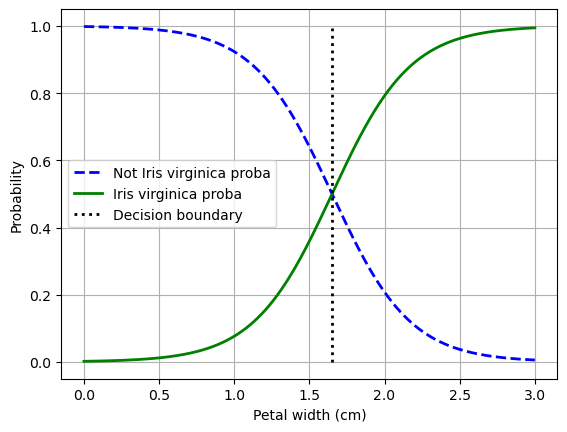

In [40]:
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba") 
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")

plt.grid(True)
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [41]:
>>> decision_boundary

np.float64(1.6516516516516517)

In [42]:
>>> log_reg.predict([[1.7], [1.5]])

array([ True, False])

In [44]:
plt.show()

SVM

In [3]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [4]:
iris = load_iris(as_frame = True)

In [5]:
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = (iris.target == 2)

In [6]:
X.shape

(150, 2)

In [7]:
y.shape

(150,)

In [8]:
svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, random_state = 42))

In [10]:
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC

In [14]:
# Create a meshgrid for the decision boundary
x0s = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
x1s = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
x0, x1 = np.meshgrid(x0s, x1s)
X_new = np.c_[x0.ravel(), x1.ravel()]

In [15]:
# Predict on the grid
y_pred = svm_clf.predict(X_new).reshape(x0.shape)

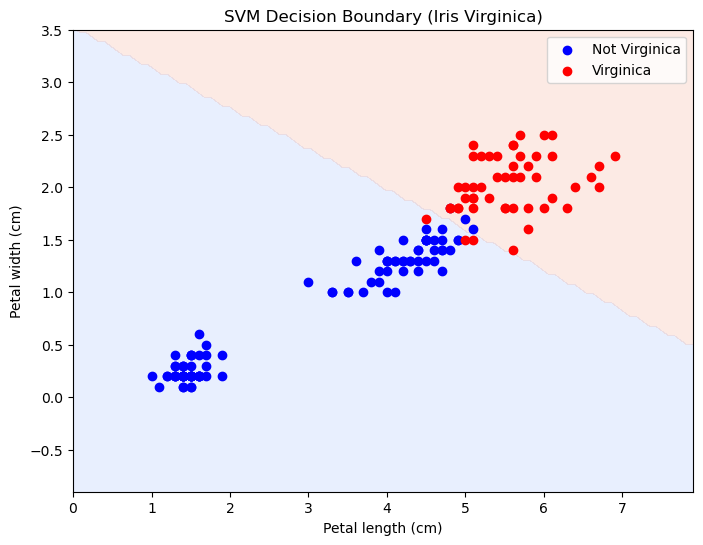

In [16]:
# Plot
plt.figure(figsize=(8, 6))
plt.contourf(x0, x1, y_pred, alpha=0.2, cmap="coolwarm")  # Decision regions
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="blue", label="Not Virginica")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="red", label="Virginica")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("SVM Decision Boundary (Iris Virginica)")
plt.legend()
plt.show()

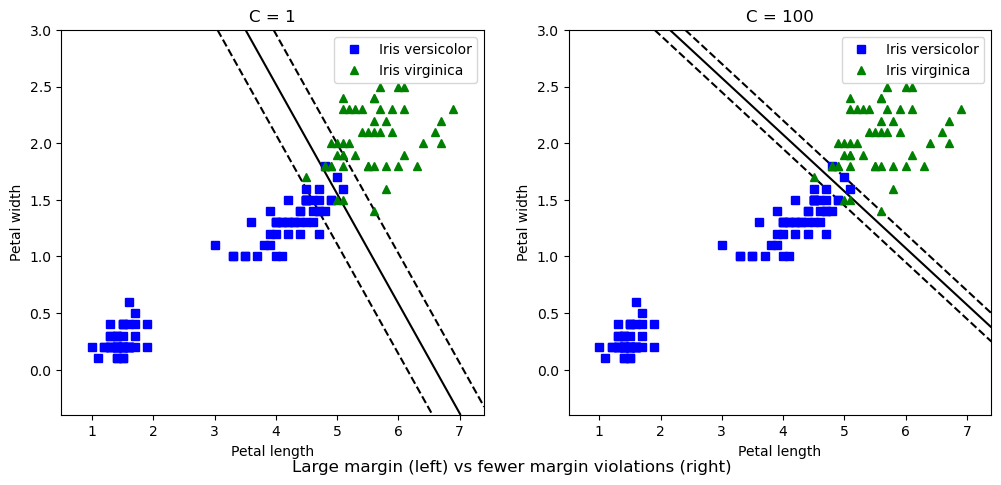

In [19]:
# Function to plot decision boundary
def plot_svc_decision_boundary(svm_clf, X, y, ax, title):
    # Get limits
    x0s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    x1s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    
    y_pred = svm_clf.decision_function(X_new).reshape(x0.shape)
    
    ax.contour(x0, x1, y_pred, colors=['k', 'k', 'k'],
               levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    
    ax.plot(X[y==0, 0], X[y==0, 1], "bs", label="Iris versicolor")
    ax.plot(X[y==1, 0], X[y==1, 1], "g^", label="Iris virginica")
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")
    ax.set_title(title)
    ax.legend()

# Train two SVMs with different C values
svm_clf1 = SVC(kernel="linear", C=1)
svm_clf2 = SVC(kernel="linear", C=100)
svm_clf1.fit(X, y)
svm_clf2.fit(X, y)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_svc_decision_boundary(svm_clf1, X, y, axes[0], "C = 1")
plot_svc_decision_boundary(svm_clf2, X, y, axes[1], "C = 100")

plt.suptitle("Large margin (left) vs fewer margin violations (right)", y=0.02)
plt.show()

In [21]:
>>> X_new = [[5.5, 1.7], [5.0, 1.5]]

In [22]:
>>> svm_clf.predict(X_new)

array([ True, False])

In [23]:
>>> svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])